In [1]:
import matplotlib.gridspec as gridspec

import sys
original_sys_path = sys.path.copy()
sys.path.append('../utils')
from utils_visualization import *

In [13]:
colors = [(0.7, 0.6, 0.0), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]


# eigenvals = qbt.eigenvals(n_evals)
# elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
def plot_fluxonium_transitions(ax,xlim,matrix, energies,qls = [0,1,2],ylim = (2e-3,0.6) ,label_small_elements = False):
    k = 13#len(energies)
    for i in qls:
        for j in range(k): 
            if j >i:
                freq_ij = np.abs(energies[i] - energies[j])  # Frequency of the transition
                element_ij = abs(matrix[i, j])  # Matrix element
                
                if element_ij > 3e-3:
                    ax.plot([freq_ij, freq_ij], [0, element_ij], marker='o',  markersize=4,color=colors[i],alpha=0.5)
                if element_ij >= 3e-3:
                    x_loc = freq_ij  #- 0.1
                    y_loc = element_ij+0.003
                    if x_loc < xlim[-1] and x_loc > xlim[0] and y_loc > ylim[0] and y_loc <ylim[-1]:
                        if x_loc< 7.5:
                            ax.text(*(x_loc-0.5,y_loc), rf'{i}-{j}', size=9,color=colors[i])
                        elif label_small_elements:
                            ax.text(*(x_loc-0.2,y_loc), rf'{i}-{j}', size=9,color=colors[i])
    ax.set_xlabel(r'$\omega_{ij}$/ $2\pi$ (GHZ)')
    ax.grid(which='major', linestyle=':', linewidth='0.5', color='grey')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_ylabel(r'$\langle i|\hat{n}|j\rangle$')
    ax.yaxis.set_label_coords(-0.1, 0.5)

def plot_sweep_Er(ax,matrix, evals,Er_list,qls = [0,1,2],ylim=(-1,1),participating_transitions = None):
    colors = ['green','red','orange']
    num_evals =len(evals)

    if participating_transitions != None:
        for i in range(num_evals):
                for j in range(num_evals): 
                    if (i, j) not in participating_transitions and (j, i) not in participating_transitions:
                        matrix[i, j] = 0 

    for ql  in qls:
        color  = colors[ql]
        linestyle = linestyles[ql]
        shift_from_qubit_transition = []
        for Er in tqdm(Er_list, desc = "Er loop"):
            shifts = [get_shift_accurate(matrix[ql,ql2], evals[ql2], evals[ql], Er) for ql2 in range(num_evals)] 
            shift_from_qubit_transition.append(sum(shifts))
        ax.plot(Er_list, shift_from_qubit_transition, label=rf'$\chi_{ql}$',color = color, linestyle = linestyle)

    ax.grid(which='major', linestyle=':', linewidth='0.5', color='black')
    ax.minorticks_on()
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='gray')
    ax.set_xlim(Er_list[0],Er_list[-1])
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlabel(rf'$\omega_r$')
    ax.legend()


In [34]:
def do(EJ_over_EC, EJ_over_EL,Er_list,ylim  = (-0.05,0.05)):
    n_evals = 20
    qbt = scqubits.Fluxonium(EJ = 4,EC = 4/EJ_over_EC,EL = 4/EJ_over_EL, cutoff = 110,flux = 0,truncated_dim=20)
    eigenvals = qbt.eigenvals(n_evals)
    elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)

    fig = plt.figure(figsize=(10, 5)) 
    gs = gridspec.GridSpec(2, 1, height_ratios=[0.7, 1], hspace=0.15)
    plot_fluxonium_transitions(ax = plt.subplot(gs[0]),matrix =  elements, energies = eigenvals,xlim = (Er_list[0],Er_list[-1]))
    plot_sweep_Er(plt.subplot(gs[1]), elements,eigenvals,Er_list,qls = [0,1,2],ylim=ylim)

    plt.tight_layout()
    plt.show()

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 89706.41it/s]
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_40773/569951657.py: 13

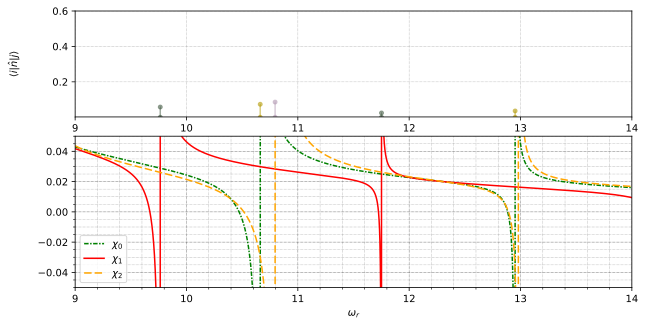

In [26]:
do(3.5,35,np.linspace(9,14,int(1e4)))

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 89952.47it/s]
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_40773/569951657.py: 13

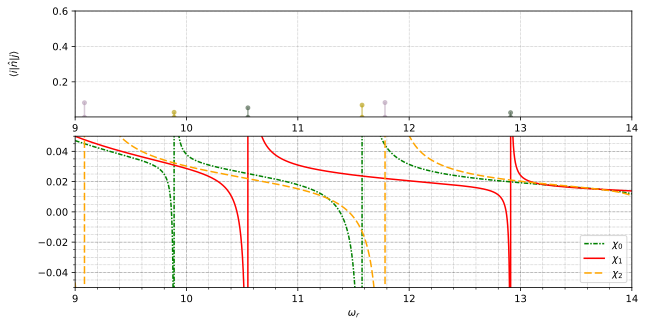

In [29]:
do(3.2,30,np.linspace(9,14,int(1e4)))

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 90833.38it/s]
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_40773/2158389357.py: 12

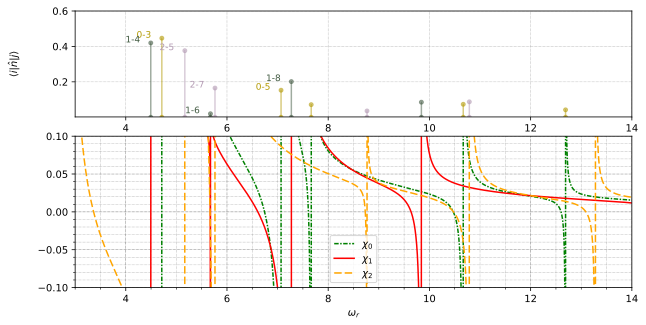

In [35]:
do(3.2,40,np.linspace(3,14,int(1e4)),ylim  = (-0.1,0.1))

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 90103.98it/s]
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_40773/2158389357.py: 12

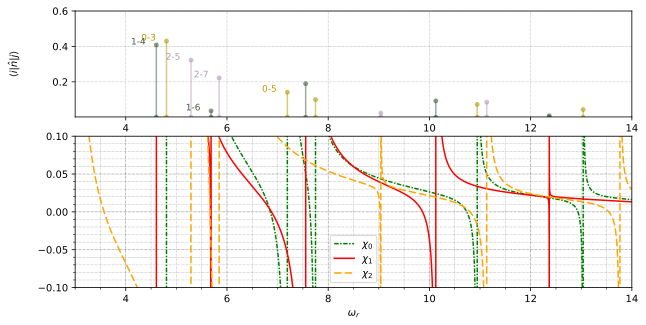

In [37]:
do(3,40,np.linspace(3,14,int(1e4)),ylim  = (-0.1,0.1))

Er loop: 100%|██████████| 10000/10000 [00:00<00:00, 90854.43it/s]
 /var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_40773/2158389357.py: 12

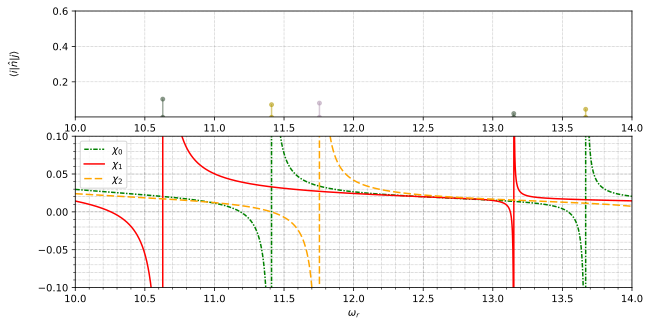

In [41]:
do(2.7,40,np.linspace(10,14,int(1e4)),ylim  = (-0.1,0.1))